#MTH 5000 – Applied Forecasting of Financial Data
##Final Forecasting Analysis
##By: Sally Zhen

### Overview: This notebook presents the results of an independent research study conducted at Baruch College. The objective of this project is to compare the performance of different forecasting approaches—statistical, machine learning, and deep learning—on real-world financial time series data. This analysis focuses specifically on **Exxon mobil**, highlighting how each methodology performs in predicting its stock price.


### Sections

#### 0. Libraries and Helper Functions

#### 1. Exploratory Data Analysis

* Pulling Data
* Calculating Statistics
* Visualizations
* Splitting and Exporting Data

---

#### 2. ARIMA and SARIMA Models

* Checking for Stationary and Autocorrelation
* Fitting ARIMA and SARIMA Models
* Checking ARIMA and SARIMA Assumptions
* ARIMA and SARIMA Forecast Visualized

---

#### 3. XGBoost Model  
* Feature Engineering for Machine Learning
* Fitting XGBoost Model
* XGBoost Forecast Results and Visualized
* XGBoost Visualized
---

#### 4. LSTM Model  
* Feature Engineering and Scaling for Neural Networks
* Fitting XGBoost Model
* XGBoost Forecast Results and Visualized
* XGBoost Visualized
---

#### 5. Comparing Results  

* Table comparing all model metrics
* Visual plot of all forecasts

---

# **Section 0**: Libraries and Helper Functions

In [1]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving fetch_data.py to fetch_data.py
Saving financial_visuals.py to financial_visuals.py
Saving residual_diagnostics.py to residual_diagnostics.py
User uploaded file "fetch_data.py" with length 1110 bytes
User uploaded file "financial_visuals.py" with length 6402 bytes
User uploaded file "residual_diagnostics.py" with length 2239 bytes


In [2]:
import fetch_data  # Module for retrieving and preprocessing financial time series data
from fetch_data import get_weekly_data  # Function to fetch weekly aggregated stock data

import financial_visuals  # Module for financial plotting utilities (EDA + forecasting visuals)
from financial_visuals import plot_financial_analysis, plot_forecast  # EDA plots and forecast comparison charts

import residual_diagnostics  # Module for model residual analysis and diagnostic testing
from residual_diagnostics import plot_residual_diagnostics  # Visual diagnostics (residuals, ACF, normality checks)

In [3]:
!pip install pmdarima

In [4]:
# Data handling
import pandas as pd  # Data manipulation and time series handling
import numpy as np   # Numerical computations and arrays

# Visualization
import matplotlib.pyplot as plt  # Base plotting library
import seaborn as sns            # Statistical visualizations (distributions, heatmaps)

# Statistics / probability
from scipy.stats import norm, kurtosis  # Normal distribution and distribution shape metrics

# Time series analysis
from statsmodels.tsa.stattools import adfuller  # Stationarity test (ADF test)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF/PACF plots for ARIMA tuning
import statsmodels.api as sm  # ARIMA / SARIMAX and statistical modeling tools

# Auto model selection
import pmdarima as pm  # Auto ARIMA for selecting optimal (p,d,q)

# Utilities
import itertools  # Grid search / parameter combinations

# Model evaluation and tuning
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Forecast accuracy metrics
from sklearn.model_selection import RandomizedSearchCV  # Randomized search with cross-validation
from sklearn.preprocessing import MinMaxScaler #Scaling data for NN

# XGBoost model
from xgboost import XGBRegressor  # Gradient boosting regression using decision trees
from xgboost import plot_importance  # Feature importance visualization

#LSTM Model
from tensorflow.keras.models import Sequential # Linear stack of neural network layers
from tensorflow.keras.layers import LSTM, Dense, Dropout ## LSTM for sequence learning, Dense for output mapping, Dropout for regularization

# **Section 1**: Exploratory Data Analysis

## **Part 1.1**: Pulling Data

In [5]:
fetch_data_df = get_weekly_data("XOM", start="2015-01-01", end = "2025-12-30",keep_columns=["Close"])

print(fetch_data_df.head())

Price           Close       High        Low       Open     Volume
Ticker            XOM        XOM        XOM        XOM        XOM
Date                                                             
2015-01-01  56.225700  57.669770  55.172085  57.173951   58984200
2015-01-08  55.618343  57.502451  54.081311  56.554200   85893300
2015-01-15  56.938450  57.012819  54.856016  56.045977   67510100
2015-01-22  54.508930  57.620187  54.428362  57.211136   69069000
2015-01-29  56.684326  57.223529  53.318965  54.676267  107202300


In [6]:
df = fetch_data_df
df

Price,Close,High,Low,Open,Volume
Ticker,XOM,XOM,XOM,XOM,XOM
Date,,,,,
2015-01-01,56.225700,57.669770,55.172085,57.173951,58984200
2015-01-08,55.618343,57.502451,54.081311,56.554200,85893300
2015-01-15,56.938450,57.012819,54.856016,56.045977,67510100
2015-01-22,54.508930,57.620187,54.428362,57.211136,69069000
2015-01-29,56.684326,57.223529,53.318965,54.676267,107202300
...,...,...,...,...,...
2025-11-27,117.020020,117.953790,113.930611,114.188884,51325700
2025-12-04,118.748497,119.672340,114.278293,116.722003,84744000


## **Part 1.2**: Calculating Statistics

In [7]:
df["Return"] = df["Close"].pct_change() #Return measures percent change in closing prices
df["Abs_Return"] = df["Return"].abs()  #Absolute Return measures Magnitude of movement without direction
df["High_Low"] = df["High"] - df["Low"] #High-Low difference measures intraday volatility
df["Open_Close_Diff"] = df["Open"] - df["Close"] #Open-Close difference measures weekly price move

In [8]:
#Preprocess and round for precision
df = df.round(3)

df.columns = df.columns.droplevel('Ticker')

In [9]:
#Descriptive Statistics
df.describe()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff
count,574.000000,574.000000,574.000000,574.000000,5.740000e+02,573.000000,573.000000,574.000000,574.000000
mean,68.408726,70.040974,66.700528,68.331946,8.353093e+07,0.002005,0.026065,3.340427,-0.076765
std,25.153983,25.709549,24.591401,25.088519,3.941335e+07,0.036601,0.025751,2.089520,2.320891
min,25.028000,27.287000,22.963000,24.901000,2.397610e+07,-0.211000,0.000000,0.616000,-9.865000
25%,52.059250,53.262250,51.151250,52.108500,5.668010e+07,-0.018000,0.008000,1.699500,-1.160000
50%,56.812500,57.631500,55.840500,56.808500,7.242475e+07,0.003000,0.019000,2.878000,-0.067500
75%,95.693500,97.963000,93.105500,95.903500,9.953115e+07,0.020000,0.036000,4.389750,1.102750
max,120.189000,120.994000,117.745000,118.321000,3.013428e+08,0.168000,0.211000,16.745000,8.352000


## **Part 1.3**: Visualizations

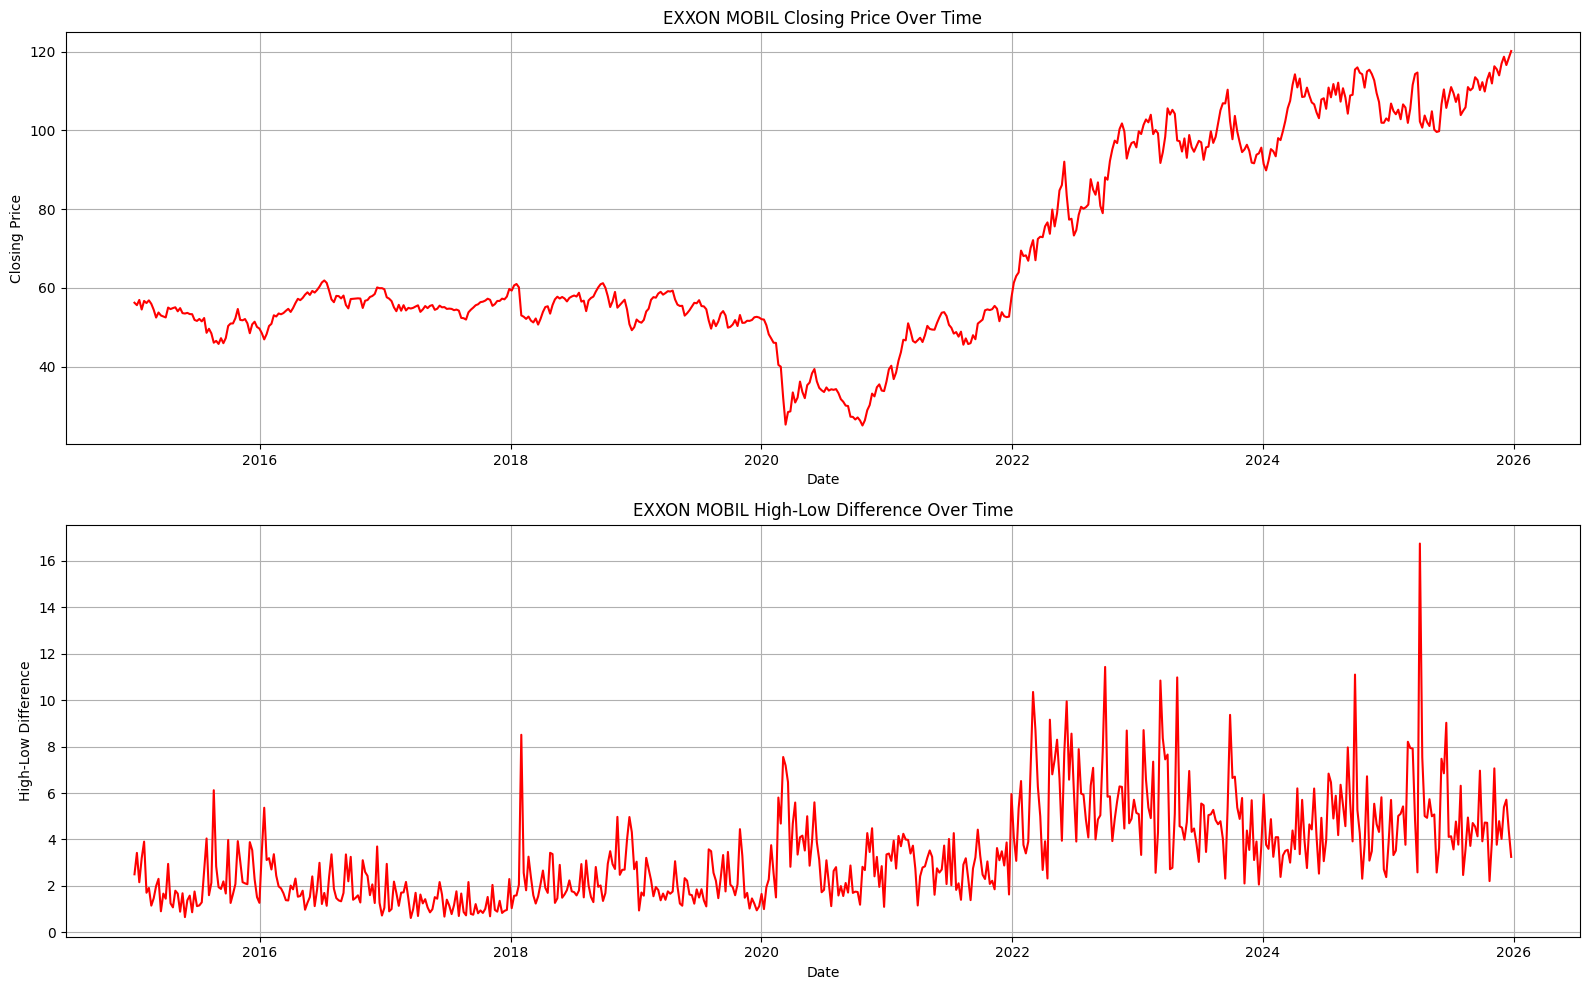

EXXON MOBIL Log Returns Excess Kurtosis: 6.000881572741875
EXXON MOBIL Open-Close Diff Excess Kurtosis: 2.1329898103370946


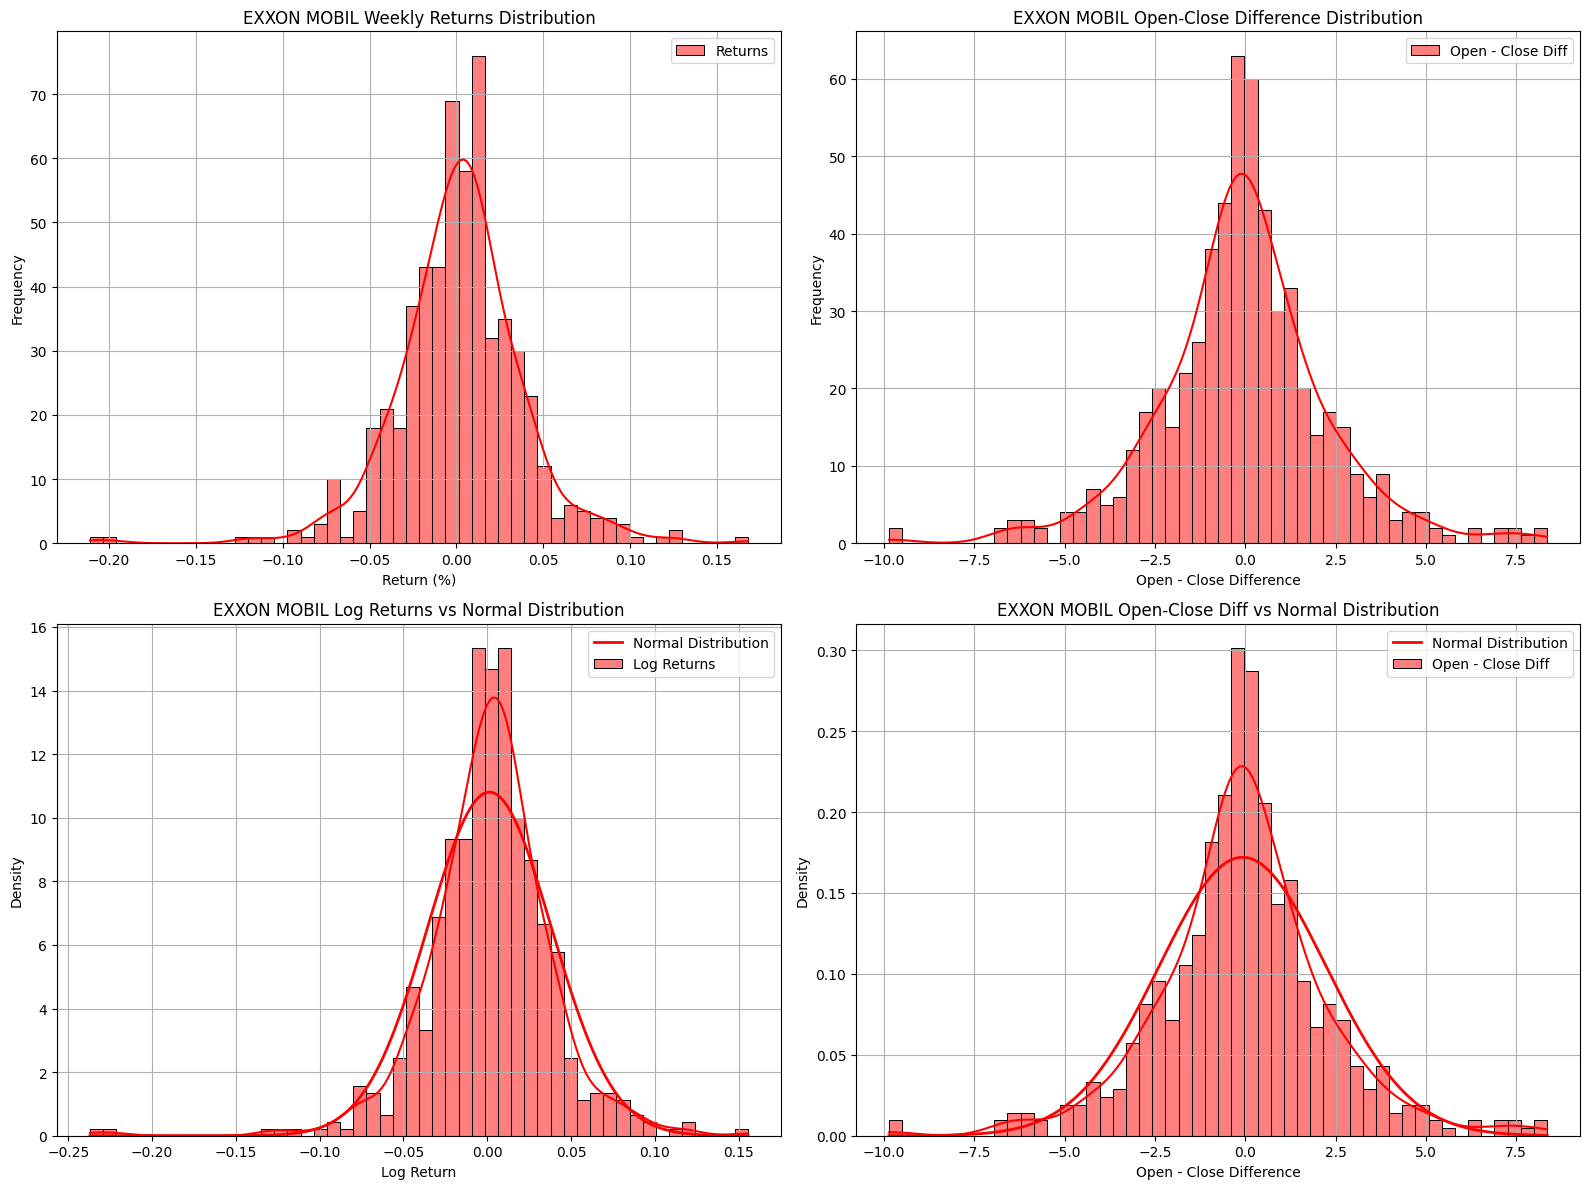

In [10]:
plot_financial_analysis(df, ticker="Exxon Mobil", color="red")

## **Part 1.4**: Splitting and Exporting Data

In [11]:
# Ensure the index is a datetime object.
df.index = pd.to_datetime(df.index)

df.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return
Date,,,,,,,,,,
2015-01-01,56.226,57.670,55.172,57.174,58984200,NaN,NaN,2.498,0.948,NaN
2015-01-08,55.618,57.502,54.081,56.554,85893300,-0.011,0.011,3.421,0.936,-0.010872
2015-01-15,56.938,57.013,54.856,56.046,67510100,0.024,0.024,2.157,-0.892,0.023456
2015-01-22,54.509,57.620,54.428,57.211,69069000,-0.043,0.043,3.192,2.702,-0.043597
2015-01-29,56.684,57.224,53.319,54.676,107202300,0.040,0.040,3.905,-2.008,0.039126


In [12]:
#Spliting data into
#Train 80% (~459 weeks (8 years))
#Test: 10%  (~115 weeks (2 years))
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

print(f"Shape of train_features: {train.shape}")
print(f"Shape of test_features: {test.shape}")

Shape of train_features: (459, 10)
Shape of test_features: (115, 10)


In [13]:
# Comment / Uncomment on final

File_name = "XOM_Forecasting.csv"

# Save to CSV
df.to_csv(File_name)

files.download(File_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Section 2**:  ARIMA and SARIMA Models

## **Part 2.1**:  Checking for Stationary and Autocorrelation

In [14]:
# Implementing the adfuller test to for Stationary
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.12952384051158009
p-value: 0.9680199673435925


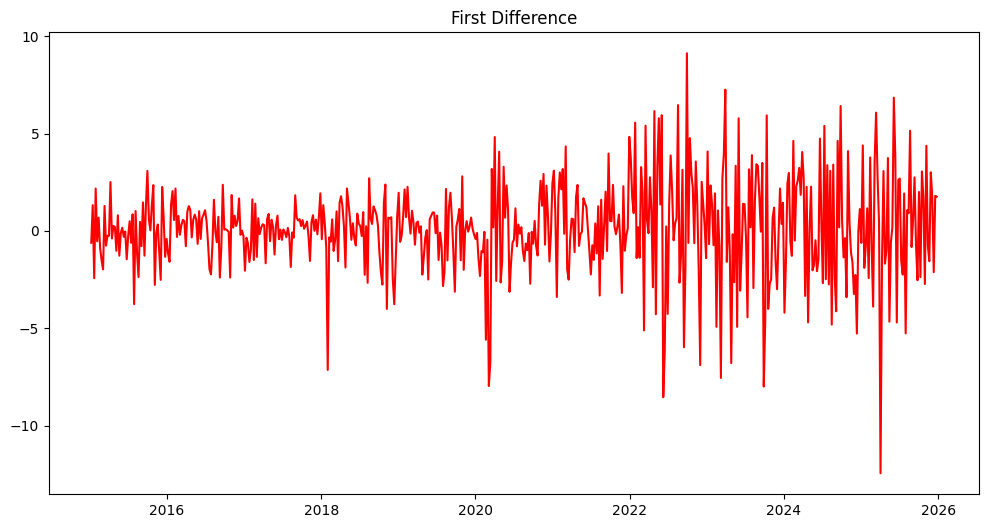

In [15]:
# Single Difference to achieve Stationarity
diff_series = df['Close'].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(diff_series, color='red')
plt.title("First Difference")
plt.show()

In [16]:
#Test again for Stationary
result_diff = adfuller(diff_series.dropna())

print("ADF Statistic (diff):", result_diff[0])
print("p-value (diff):", result_diff[1])

ADF Statistic (diff): -6.370598862456426
p-value (diff): 2.3503198076086408e-08


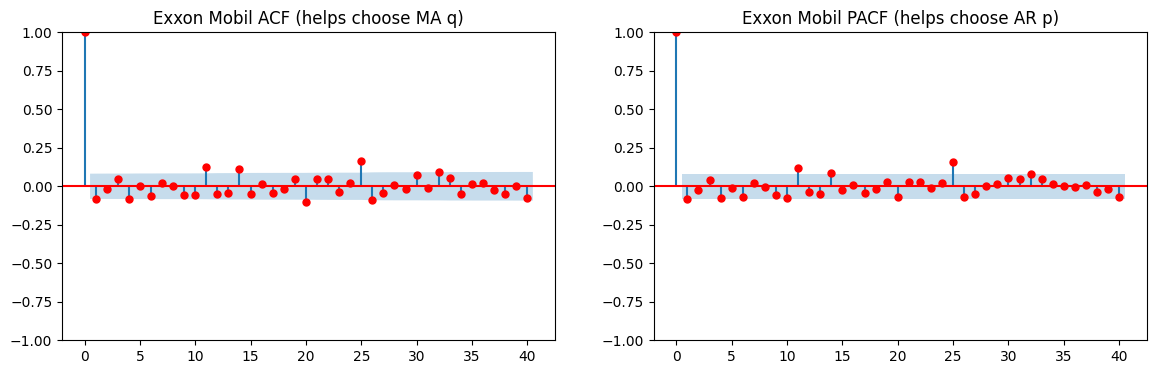

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF (MA terms)
plot_acf(diff_series, lags=40, ax=axes[0])
axes[0].set_title("Exxon Mobil ACF (helps choose MA q)")

for line in axes[0].lines:
    line.set_color('red')

# PACF (AR terms)
plot_pacf(diff_series, lags=40, ax=axes[1])
axes[1].set_title("Exxon Mobil PACF (helps choose AR p)")

for line in axes[1].lines:
    line.set_color('red')

plt.show()

## **Part 2.2**:  Fitting ARIMA and SARIMA Models

In [18]:
auto_model_search = pm.auto_arima(
    train['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,            # let auto_arima determine the differencing
    seasonal=False,     # Enable seasonality
    m=52,              # Set seasonal period to 52 for weekly data
    stepwise=True,     # faster stepwise search
    trace=True         # shows progress
)

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:62: UserWarning: m (52) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2026.493, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2027.086, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2027.119, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2025.508, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2029.076, Time=0.84 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.661 seconds


In [19]:
# Best parameters from the search
p, d, q = 0, 1, 0

auto_model = sm.tsa.statespace.SARIMAX(
    train['Close'],
    order=(p, d, q),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  459
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1010.006
Date:                Sun, 03 May 2026   AIC                           2022.013
Time:                        14:24:20   BIC                           2026.137
Sample:                    01-01-2015   HQIC                          2023.637
                         - 10-12-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.8660      0.210     23.152      0.000       4.454       5.278
Ljung-Box (L1) (Q):                   1.37   Jarque-Bera (JB):               154.19
Prob(Q):                              0.24   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


In [20]:
# Comment / Uncomment on final

#Searching through parameters
p_vals = [1, 2, 3]
q_vals = [0, 1]
P_vals = [0, 1]
Q_vals = [0, 1]

d, D, m = 1, 1, 52   # FIXED

results = []

for p, q in itertools.product(p_vals, q_vals):
    for P, Q in itertools.product(P_vals, Q_vals):
        try:
            model = sm.tsa.statespace.SARIMAX(
                train['Close'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=50)

            results.append(((p,d,q,P,D,Q), model.aic))
            print((p,d,q,P,D,Q), "AIC:", model.aic)

        except Exception:
            continue

results.sort(key=lambda x: x[1])

print("\nTop 5 models:")
for r in results[:5]:
    print(r)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


(1, 1, 0, 0, 1, 0) AIC: 2032.9089497092925


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


(1, 1, 0, 0, 1, 1) AIC: 1668.970978285578


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


...

(3, 1, 1, 0, 1, 1) AIC: 1667.477449620074


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


(3, 1, 1, 1, 1, 0) AIC: 1697.5983971148075


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


(3, 1, 1, 1, 1, 1) AIC: 1668.213005599906

Top 5 models:
((1, 1, 1, 0, 1, 1), np.float64(1664.1381300152239))
((2, 1, 1, 0, 1, 1), np.float64(1665.6441561000443))
((3, 1, 1, 0, 1, 1), np.float64(1667.477449620074))
((3, 1, 0, 1, 1, 1), np.float64(1667.5144603525073))
((3, 1, 1, 1, 1, 1), np.float64(1668.213005599906))


In [21]:
# Best parameters from the search
p, d, q = 1, 1, 1
P, D, Q, m = 0, 1, 1, 52

seasonal_auto_model = sm.tsa.statespace.SARIMAX(
    train['Close'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(seasonal_auto_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  459
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood                -828.069
Date:                            Sun, 03 May 2026   AIC                           1664.138
Time:                                    14:35:05   BIC                           1679.593
Sample:                                01-01-2015   HQIC                          1670.288
                                     - 10-12-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9324      0.049    -19.114      0.000      -1.028      -0.837
ma.L1          0.9676      0.035   

In [22]:
#Getting predictions from ARIMA and SARIMA models
forecast = auto_model.get_forecast(steps=len(test)).predicted_mean
seasonal_forecast = seasonal_auto_model.get_forecast(steps=len(test)).predicted_mean

In [23]:
#ARIMA metrics
mse__ARIMA = (mean_squared_error(test['Close'], forecast))
mae__ARIMA = mean_absolute_error(test['Close'], forecast)
rmse_ARIMA = np.sqrt(mean_squared_error(test['Close'], forecast))
mape_ARIMA = np.mean(np.abs((test['Close'] - forecast) / test['Close'])) * 100

print(f"MSE:  {mse__ARIMA:.4f}")
print(f"MAE:  {mae__ARIMA:.4f}")
print(f"RMSE: {rmse_ARIMA:.4f}")
print(f"MAPE: {mape_ARIMA:.4f}%")

MSE:  56.7622
MAE:  6.3969
RMSE: 7.5341
MAPE: 5.9787%


In [24]:
#SARIMA metrics
mse_SARIMA = (mean_squared_error(test['Close'], seasonal_forecast))
mae_SARIMA = mean_absolute_error(test['Close'], seasonal_forecast)
rmse_SARIMA = np.sqrt(mean_squared_error(test['Close'], seasonal_forecast))
mape_SARIMA = np.mean(np.abs((test['Close'] - seasonal_forecast) / test['Close'])) * 100

print(f"MSE:  {mse_SARIMA:.4f}")
print(f"MAE:  {mae_SARIMA:.4f}")
print(f"RMSE: {rmse_SARIMA:.4f}")
print(f"MAPE: {mape_SARIMA:.4f}%")

MSE:  147.4648
MAE:  10.4158
RMSE: 12.1435
MAPE: 10.0121%


## **Part 2.3**:  Checking ARIMA and SARIMA Assumptions

ARIMA Assumptions
EXXON MOBIL Residual Mean: 0.22594989106753816


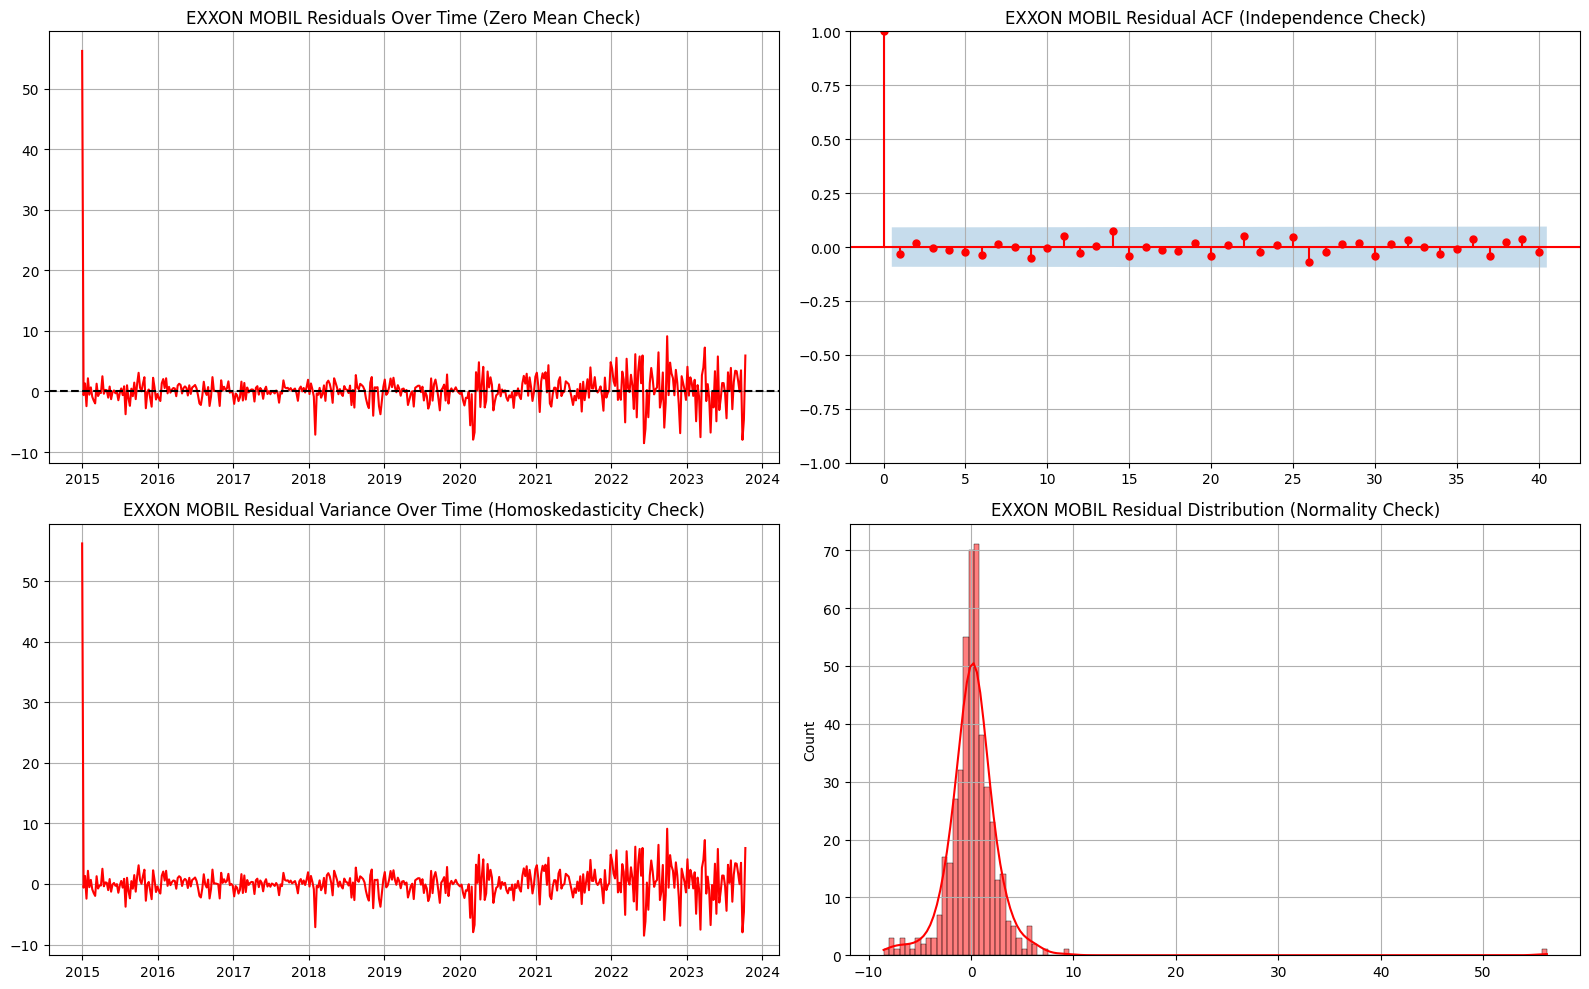

In [25]:
print("ARIMA Assumptions")
plot_residual_diagnostics(fit=auto_model, ticker="Exxon Mobil", color="red")

SARIMA Assumptions
EXXON MOBIL Residual Mean: 0.11998106721616536


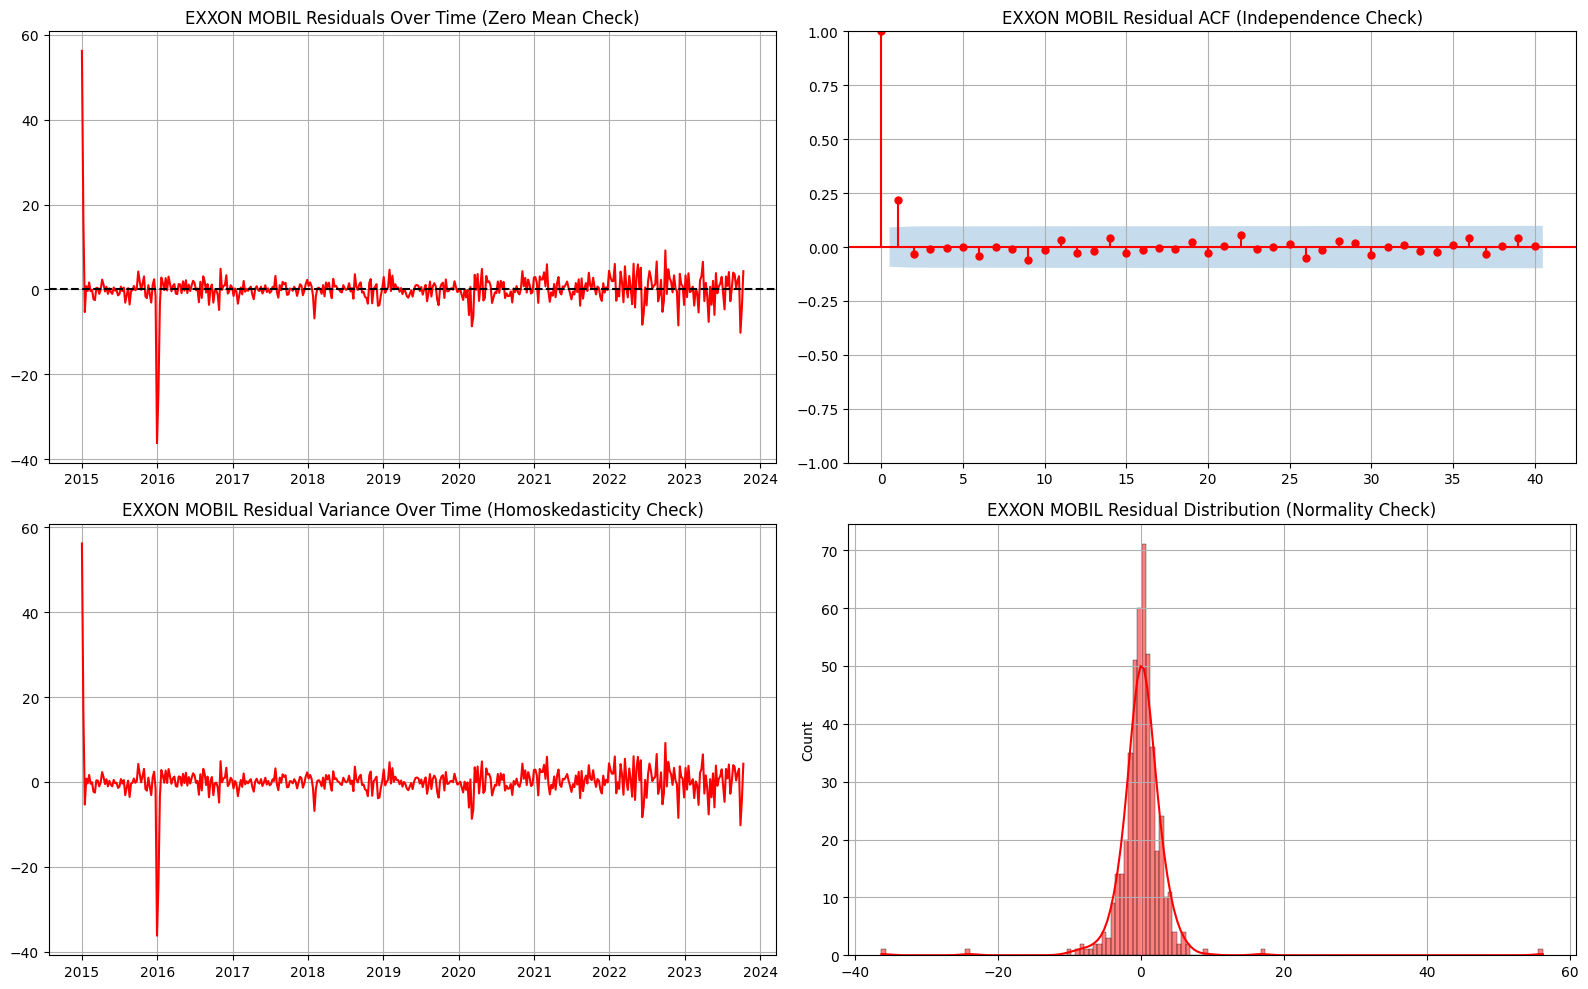

In [26]:
print("SARIMA Assumptions")
plot_residual_diagnostics(fit=seasonal_auto_model, ticker="Exxon Mobil", color="red")

## **Part 2.4**:  ARIMA and SARIMA Forecast Visualized

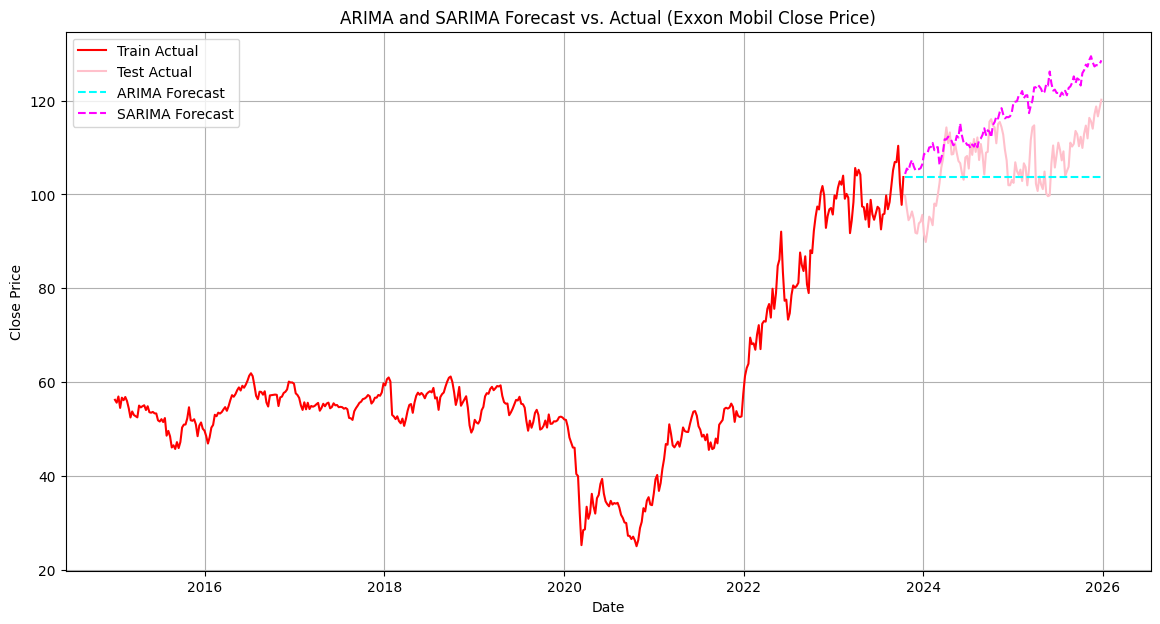

In [27]:
plt.figure(figsize=(14, 7))
plt.plot(train['Close'], label='Train Actual', color='red')
plt.plot(test['Close'], label='Test Actual', color='pink')
plt.plot(forecast, label='ARIMA Forecast', color='cyan', linestyle='--')
plt.plot(seasonal_forecast, label='SARIMA Forecast', color='magenta', linestyle='--')

plt.title('ARIMA and SARIMA Forecast vs. Actual (Exxon Mobil Close Price)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 3**: XGBoost Model  

In [28]:
df

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return
Date,,,,,,,,,,
2015-01-01,56.226,57.670,55.172,57.174,58984200,NaN,NaN,2.498,0.948,NaN
2015-01-08,55.618,57.502,54.081,56.554,85893300,-0.011,0.011,3.421,0.936,-0.010872
2015-01-15,56.938,57.013,54.856,56.046,67510100,0.024,0.024,2.157,-0.892,0.023456
2015-01-22,54.509,57.620,54.428,57.211,69069000,-0.043,0.043,3.192,2.702,-0.043597
2015-01-29,56.684,57.224,53.319,54.676,107202300,0.040,0.040,3.905,-2.008,0.039126
...,...,...,...,...,...,...,...,...,...,...
2025-11-27,117.020,117.954,113.931,114.189,51325700,0.026,0.026,4.023,-2.831,0.026059
2025-12-04,118.748,119.672,114.278,116.722,84744000,0.015,0.015,5.394,-2.026,0.014659
2025-12-11,116.633,119.563,113.851,118.321,81740900,-0.018,0.018,5.712,1.689,-0.017971


## **Part 3.1**:  Feature Engineering for Machine Learning


In [29]:
# Copy df for feature engineering
df_features = df.copy()

# Reset the index to make 'Date' a regular column
df_features = df_features.reset_index()

# Extract time-based features
df_features['year'] = df_features['Date'].dt.year
df_features['month'] = df_features['Date'].dt.month
df_features['day'] = df_features['Date'].dt.day
df_features['dayofweek'] = df_features['Date'].dt.dayofweek
df_features['dayofyear'] = df_features['Date'].dt.dayofyear
df_features['weekofyear'] = df_features['Date'].dt.isocalendar().week.astype(int)

# Drop the original 'Date' column as it's no longer needed in its original form
df_features = df_features.drop(columns=['Date'])

# Display basic info
df_features.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return,year,month,day,dayofweek,dayofyear,weekofyear
0,56.226,57.670,55.172,57.174,58984200,NaN,NaN,2.498,0.948,NaN,2015,1,1,3,1,1
1,55.618,57.502,54.081,56.554,85893300,-0.011,0.011,3.421,0.936,-0.010872,2015,1,8,3,8,2
2,56.938,57.013,54.856,56.046,67510100,0.024,0.024,2.157,-0.892,0.023456,2015,1,15,3,15,3
3,54.509,57.620,54.428,57.211,69069000,-0.043,0.043,3.192,2.702,-0.043597,2015,1,22,3,22,4
4,56.684,57.224,53.319,54.676,107202300,0.040,0.040,3.905,-2.008,0.039126,2015,1,29,3,29,5


In [30]:
# Assume the target column is named 'Close' (change if needed)
target_col = 'Close'

# Create lag features
def create_lags(data, col, lags=5):
    df_features = data.copy()
    for i in range(1, lags+1):
        df_features[f'lag_{i}'] = df_features[col].shift(i)
    return df_features

df_features = create_lags(df_features, target_col, lags=10)

# Drop NA values from lagging
df_features = df_features.dropna()

df_features.head()

Price,Close,High,Low,Open,Volume,Return,Abs_Return,High_Low,Open_Close_Diff,Log_Return,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
10,53.745,53.933,51.628,52.721,72834400,0.024,0.024,2.304,-1.024,0.024104,...,52.465,54.438,55.950,56.830,56.151,56.684,54.509,56.938,55.618,56.226
11,52.990,53.564,52.659,53.196,88381700,-0.014,0.014,0.905,0.206,-0.014147,...,53.745,52.465,54.438,55.950,56.830,56.151,56.684,54.509,56.938,55.618
12,52.740,53.702,52.034,53.264,69509500,-0.005,0.005,1.667,0.525,-0.004729,...,52.990,53.745,52.465,54.438,55.950,56.830,56.151,56.684,54.509,56.938
13,52.490,53.808,52.359,52.509,50307000,-0.005,0.005,1.449,0.019,-0.004752,...,52.740,52.990,53.745,52.465,54.438,55.950,56.830,56.151,56.684,54.509
14,55.000,55.281,52.334,52.453,67561300,0.048,0.048,2.947,-2.548,0.046711,...,52.490,52.740,52.990,53.745,52.465,54.438,55.950,56.830,56.151,56.684


In [31]:
#Spliting our feature engineered data into
#Train 80% (~451 weeks (8 years))
#Test: 10%  (~113 weeks (2 years))
train_size = int(len(df_features) * 0.8)

train_features = df_features.iloc[:train_size]
test_features = df_features.iloc[train_size:]

X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]

X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]


print(f"Shape of train_features: {train_features.shape}")
print(f"Shape of test_features: {test_features.shape}")

Shape of train_features: (451, 26)
Shape of test_features: (113, 26)


## **Part 3.2**: Fitting XGBoost Model


In [32]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=50),
    params,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error')

In [33]:
results = pd.DataFrame(search.cv_results_)
results.sort_values("rank_test_score")[[
    "params",
    "mean_test_score",
    "rank_test_score"
]]

best_model = search.best_estimator_
search.best_params_

{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}

## **Part 3.3**: XGBoost Forecast Results

In [34]:
# Predictions
preds = best_model.predict(X_test)

#XGBoost Metrics
mse_XGBoost  = mean_squared_error(y_test, preds)
mae_XGBoost  = mean_absolute_error(y_test, preds)
rmse_XGBoost = np.sqrt(mean_squared_error(y_test, preds))
mape_XGBoost = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"MSE:  {mse_XGBoost:.4f}")
print(f"MAE:  {mae_XGBoost:.4f}")
print(f"RMSE: {rmse_XGBoost:.4f}")
print(f"MAPE: {mape_XGBoost:.4f}%")

MSE:  21.5520
MAE:  3.3434
RMSE: 4.6424
MAPE: 2.9989%


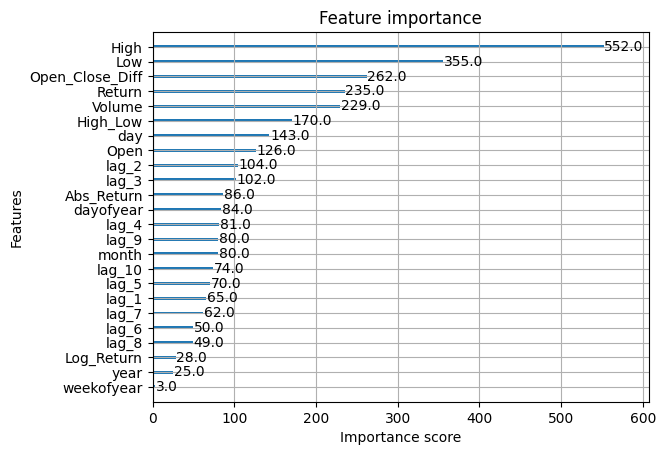

In [35]:
plot_importance(best_model)
plt.show()

## **Part 3.4**: XGBoost Visualized

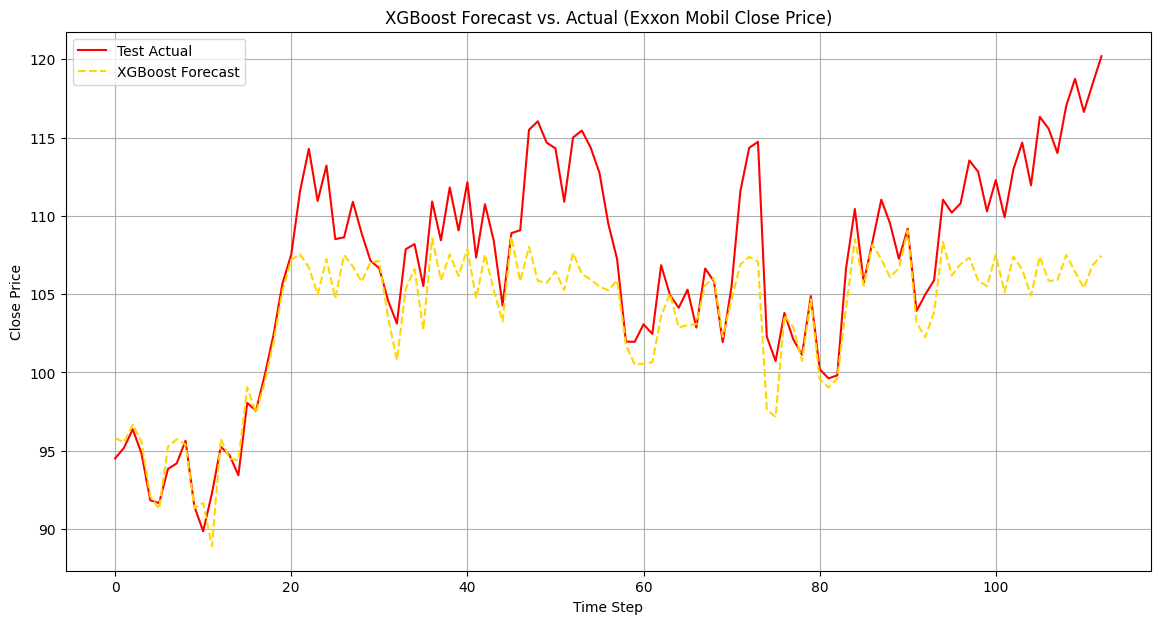

In [36]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Test Actual', color='red')
plt.plot(preds, label='XGBoost Forecast', color='gold', linestyle='--')

plt.title('XGBoost Forecast vs. Actual (Exxon Mobil Close Price)')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 4**: LSTM Model  

In [37]:
df_stripped = df.replace([np.inf, -np.inf], np.nan)
df_stripped = df_stripped.dropna()

## **Part 4.1**:  Feature Engineering and Scaling for Neural Networks

In [38]:
features = ['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'High_Low', 'Open_Close_Diff', 'Abs_Return']

data = df_stripped[features]

data.head()

Price,Close,High,Low,Open,Volume,Return,High_Low,Open_Close_Diff,Abs_Return
Date,,,,,,,,,
2015-01-08,55.618,57.502,54.081,56.554,85893300,-0.011,3.421,0.936,0.011
2015-01-15,56.938,57.013,54.856,56.046,67510100,0.024,2.157,-0.892,0.024
2015-01-22,54.509,57.620,54.428,57.211,69069000,-0.043,3.192,2.702,0.043
2015-01-29,56.684,57.224,53.319,54.676,107202300,0.040,3.905,-2.008,0.040
2015-02-05,56.151,57.354,55.649,57.261,61694400,-0.009,1.704,1.109,0.009


In [39]:
#scaling data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [40]:
#Sliding Window
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X, y = create_sequences(scaled_data, 60)
X.shape, y.shape

((513, 60, 9), (513,))

In [41]:
split = int(0.8 * len(X))
X_stripped_train = X[:split]
X_stripped_test = X[split:]
y_stripped_train = y[:split]
y_stripped_test = y[split:]

print("X shape:", X.shape)


X shape: (513, 60, 9)


## **Part 4.2**: Fitting LSTM Model

In [42]:
def build_model():
    model = Sequential()

    model.add(LSTM(
        64,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    ))

    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(32))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [43]:
model = build_model()

history = model.fit(
    X_stripped_train, y_stripped_train,
    epochs=70,
    batch_size=32,
    validation_data=(X_stripped_test, y_stripped_test)
)

# Training loss (final epoch value)
train_loss = history.history['loss'][-1]

# Validation loss (final epoch value)
val_loss = history.history['val_loss'][-1]

print(train_loss)
print(val_loss)


Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - loss: 0.0471 - val_loss: 0.0544
Epoch 2/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 0.0076 - val_loss: 0.0027
Epoch 3/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0052 - val_loss: 0.0029
Epoch 4/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 5/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 6/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0038 - val_loss: 0.0070
Epoch 7/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 8/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 9/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0034 - val_loss: 0.0022
Epoch 10/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 11/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 12/70
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0027 - val

## **Part 4.3**: LSTM Forecast Results

In [44]:
predictions = model.predict(X_stripped_test)

#Convert Predictions Back to Original Scale
# create empty array to match original feature size
predicted_full = np.zeros((len(predictions), data.shape[1]))
predicted_full[:, 0] = predictions[:, 0]  # assuming 'Close' is index 0

predicted_prices = scaler.inverse_transform(predicted_full)[:, 0]

# actual values
actual_full = np.zeros((len(y_stripped_test), data.shape[1]))
actual_full[:, 0] = y_stripped_test

actual_prices = scaler.inverse_transform(actual_full)[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


In [45]:
mse_lstm = mean_squared_error(actual_prices, predicted_prices)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(actual_prices, predicted_prices)
mape_lstm = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print(mse_lstm)
print(rmse_lstm)
print(mae_lstm)
print(mape_lstm)

16.079410198786505
4.009913988951197
3.3070457050221678
3.039926374291282


## **Part 4.4**: LSTM Visualized

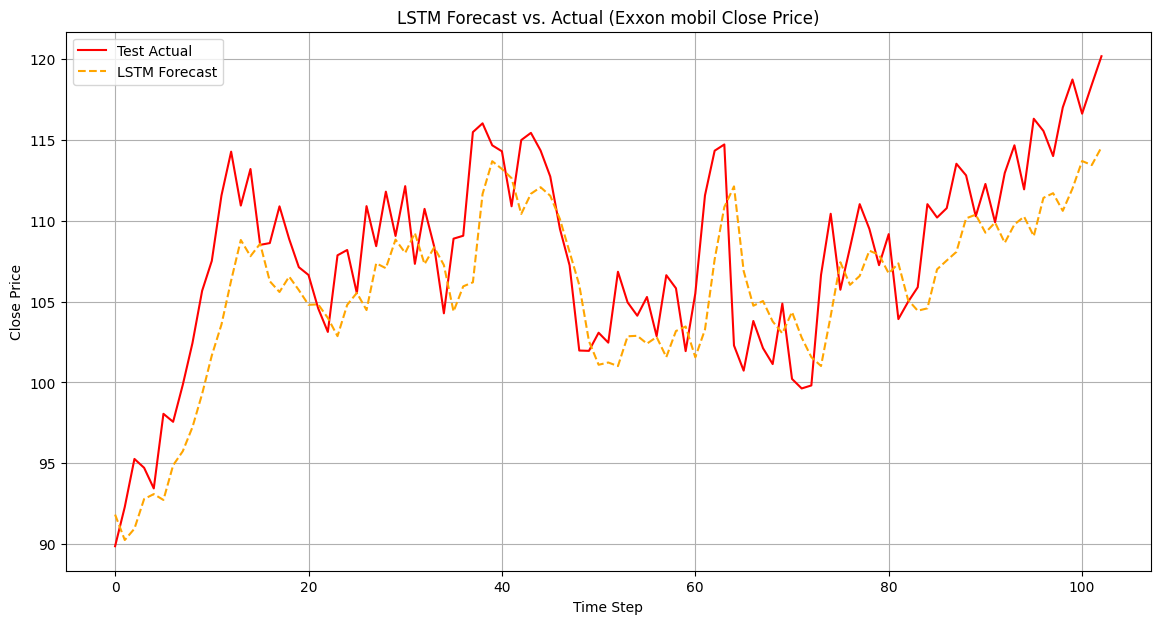

In [46]:
plt.figure(figsize=(14, 7))
plt.plot(actual_prices, label='Test Actual', color='red')
plt.plot(predicted_prices, label='LSTM Forecast', color='orange', linestyle='--')

plt.title('LSTM Forecast vs. Actual (Exxon mobil Close Price)')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# **Section 5**: Comparing Results    

## **Part 5.1**: Table comparing all model metrics

In [47]:
# Create a dictionary to hold the metrics for each model
metrics_data = {
    'Model': ['ARIMA', 'SARIMA', 'XGBoost', 'LSTM'],
    'MSE': [mse__ARIMA, mse_SARIMA, mse_XGBoost, mse_lstm],
    'MAE': [mae__ARIMA, mae_SARIMA, mae_XGBoost, mae_lstm],
    'RMSE': [rmse_ARIMA, rmse_SARIMA, rmse_XGBoost, rmse_lstm],
    'MAPE (%)': [mape_ARIMA, mape_SARIMA, mape_XGBoost, mape_lstm]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame
display(metrics_df.round(4))

,Model,MSE,MAE,RMSE,MAPE (%)
0,ARIMA,56.7622,6.3969,7.5341,5.9787
1,SARIMA,147.4648,10.4158,12.1435,10.0121
2,XGBoost,21.5520,3.3434,4.6424,2.9989
3,LSTM,16.0794,3.3070,4.0099,3.0399


## **Part 5.2**: Visual plot of all forecasts

In [48]:
forecasts = {
    "ARIMA Forecast": (forecast, 'cyan'),
    "SARIMA Forecast": (seasonal_forecast, 'magenta'),
    "XGBoost Forecast": (preds, 'gold'),
    "LSTM Forecast": (predicted_prices, 'orange')
}

common_test_actual = test['Close']

In [49]:
fig = plot_forecast(
    df,
    train,
    common_test_actual,
    forecasts,
    ticker='Exxon mobil',
    template='presentation',
    test_color='pink',
    actual_color='red'
)

fig.show()